In [ ]:
import pandas as pd

# Все наши вопросы (ID, Категория, EN, RU, KK, UZ)
raw_data = [
    # --- FACT ---
    ("FACT_01", "Fact", "What is the capital of France?", "Какая столица Франции?", "Францияның астанасы қандай?", "Fransiyaning poytaxti qaysi shahar?"),
    ("FACT_02", "Fact", "Who wrote the play 'Romeo and Juliet'?", "Кто написал пьесу 'Ромео и Джульетта'?", "'Ромео мен Джульетта' пьесасын кім жазды?", "'Romeo va Julietta' pyesasini kim yozgan?"),
    ("FACT_03", "Fact", "What is the chemical symbol for gold?", "Каков химический символ золота?", "Алтынның химиялық символы қандай?", "Oltinning kimyoviy belgisi qanday?"),
    ("FACT_04", "Fact", "In what year did World War II end?", "В каком году закончилась Вторая мировая война?", "Екінші дүниежүзілік соғыс қай жылы аяқталды?", "Ikkinchi jahon urushi nechanchi yilda tugagan?"),
    ("FACT_05", "Fact", "What is the largest planet in the Solar System?", "Какая планета самая большая в Солнечной системе?", "Күн жүйесіндегі ең үлкен ғаламшар (планета) қайсысы?", "Quyosh tizimidagi eng yirik sayyora qaysi?"),
    ("FACT_06", "Fact", "Who painted the Mona Lisa?", "Кто написал картину 'Мона Лиза'?", "'Мона Лиза' картинасын кім салды?", "'Mona Liza' kartinasini kim chizgan?"),
    ("FACT_07", "Fact", "What is the boiling point of water at sea level, in Celsius?", "Какова температура кипения воды на уровне моря в градусах Цельсия?", "Теңіз деңгейіндегі судың қайнау температурасы Цельсий бойынша қанша градус?", "Dengiz sathida suvning qaynash harorati Selsiy bo'yicha necha gradus?"),
    ("FACT_08", "Fact", "What is the longest river in the world?", "Какая река самая длинная в мире?", "Әлемдегі ең ұзын өзен қайсысы?", "Dunyodagi eng uzun daryo qaysi?"),
    ("FACT_09", "Fact", "Which gas do plants absorb from the atmosphere during photosynthesis?", "Какой газ растения поглощают из атмосферы во время фотосинтеза?", "Фотосинтез кезінде өсімдіктер атмосферадан қандай газды сіңіреді?", "O'simliklar fotosintez jarayonida atmosferadan qaysi gazni yutadi?"),
    ("FACT_10", "Fact", "Who was the first President of the United States?", "Кто был первым президентом Соединенных Штатов?", "Америка Құрама Штаттарының бірінші президенті кім болды?", "Amerika Qo'shma Shtatlarining birinchi prezidenti kim bo'lgan?"),
    ("FACT_11", "Fact", "What is the smallest prime number?", "Какое самое маленькое простое число?", "Ең кішкентай жай сан қандай?", "Eng kichik tub son qaysi?"),
    ("FACT_12", "Fact", "What is the currency used in Japan?", "Какая валюта используется в Японии?", "Жапонияда қандай валюта қолданылады?", "Yaponiyada qanday valyutadan foydalaniladi?"),
    ("FACT_13", "Fact", "How many continents are there on Earth?", "Сколько континентов на Земле?", "Жер бетінде неше құрлық (континент) бар?", "Yer yuzida nechta qit'a bor?"),
    ("FACT_14", "Fact", "What is the speed of light in a vacuum, approximately, in km/s?", "Какова приблизительная скорость света в вакууме в км/с?", "Вакуумдегі жарық жылдамдығы шамамен қанша км/с құрайды?", "Vakuumda yorug'lik tezligi taxminan necha km/s ga teng?"),
    ("FACT_15", "Fact", "Who developed the theory of general relativity?", "Кто создал общую теорию относительности?", "Жалпы салыстырмалылық теориясын кім жасады?", "Umumiy nisbiylik nazariyasini kim ishlab chiqqan?"),
    ("FACT_16", "Fact", "What is the tallest mountain in the world?", "Какая гора самая высокая в мире?", "Әлемдегі ең биік тау қайсысы?", "Dunyodagi eng baland tog' qaysi?"),
    ("FACT_17", "Fact", "What is the main language spoken in Brazil?", "На каком основном языке говорят в Бразилии?", "Бразилияда негізінен қандай тілде сөйлейді?", "Braziliyada asosan qaysi tilda gaplashishadi?"),
    ("FACT_18", "Fact", "What organ in the human body pumps blood?", "Какой орган в теле человека перекачивает кровь?", "Адам ағзасында қанды қандай орган айдайды?", "Inson tanasida qaysi a'zo qonni haydaydi?"),
    ("FACT_19", "Fact", "What is the freezing point of water in Fahrenheit?", "Какова температура замерзания воды в градусах Фаренгейта?", "Фаренгейт бойынша судың қату температурасы қандай?", "Farengeyt bo'yicha suvning muzlash harorati qanday?"),
    ("FACT_20", "Fact", "Which ocean is the largest by surface area?", "Какой океан самый большой по площади поверхности?", "Жер бетіндегі ауданы бойынша ең үлкен мұхит қайсысы?", "Maydoni bo'yicha eng yirik okean qaysi?"),

    # --- LOGIC ---
    ("LOGIC_01", "Logic", "If all cats are mammals, and all mammals are animals, are all cats animals? Answer yes or no and explain why.", "Если все кошки — млекопитающие, а все млекопитающие — животные, являются ли все кошки животными? Ответьте да или нет и объясните почему.", "Егер барлық мысықтар сүтқоректілер болса, ал барлық сүтқоректілер жануарлар болса, онда барлық мысықтар жануарлар ма? Иә немесе жоқ деп жауап беріңіз және себебін түсіндіріңіз.", "Agar barcha mushuklar sutemizuvchilar bo'lsa va barcha sutemizuvchilar hayvonlar bo'lsa, barcha mushuklar hayvonlarmi? Ha yoki yo'q deb javob bering va sababini tushuntiring."),
    ("LOGIC_02", "Logic", "A train leaves the station at 3:00 PM and travels for 2 hours and 45 minutes. What time does it arrive?", "Поезд отправляется со станции в 15:00 и находится в пути 2 часа 45 минут. В какое время он прибывает?", "Пойыз станциядан сағат 15:00-де шығып, 2 сағат 45 минут жол жүреді. Ол қай уақытта жетеді?", "Poyezd stansiyadan soat 15:00 da yo'lga chiqdi va 2 soat 45 daqiqa harakatlandi. U qachon yetib keladi?"),
    ("LOGIC_03", "Logic", "If today is Wednesday, what day of the week will it be in 10 days?", "Если сегодня среда, какой день недели будет через 10 дней?", "Егер бүгін сәрсенбі болса, 10 күннен кейін аптаның қай күні болады?", "Agar bugun chorshanba bo'lsa, 10 kundan keyin haftaning qaysi kuni bo'ladi?"),
    ("LOGIC_04", "Logic", "Tom is taller than Ben. Ben is taller than Sam. Who is the shortest?", "Том выше Бена. Бен выше Сэма. Кто самый низкий?", "Том Беннен ұзын. Бен Сэмнен ұзын. Ең қысқасы кім?", "Tom Bendan uzunroq. Ben Semdan uzunroq. Eng bo'yi pasti kim?"),
    ("LOGIC_05", "Logic", "If 5 apples cost $2, how much do 15 apples cost?", "Если 5 яблок стоят 2 доллара, сколько стоят 15 яблок?", "Егер 5 алма 2 доллар тұрса, 15 алма қанша тұрады?", "Agar 5 ta olma 2 dollar tursa, 15 ta olma qancha turadi?"),
    ("LOGIC_06", "Logic", "A farmer has 3 fields. Each field has 12 rows, and each row has 8 plants. How many plants are there in total?", "У фермера 3 поля. На каждом поле 12 рядов, а в каждом ряду по 8 растений. Сколько всего растений?", "Фермердің 3 егістігі бар. Әр егістікте 12 қатар, ал әр қатарда 8 өсімдік бар. Барлығы неше өсімдік бар?", "Fermerning 3 ta dalasi bor. Har bir dalada 12 ta qator va har bir qatorda 8 tadan o'simlik bor. Jami nechta o'simlik bor?"),
    ("LOGIC_07", "Logic", "If it is true that 'all birds can fly' and 'a penguin is a bird,' what logical problem arises with the statement 'all birds can fly'?", "Если верно, что 'все птицы умеют летать' и 'пингвин — это птица', какая логическая проблема возникает с утверждением 'все птицы умеют летать'?", "Егер 'барлық құстар ұша алады' және 'пингвин — құс' деген рас болса, 'барлық құстар ұша алады' деген тұжырымда қандай логикалық мәселе туындайды?", "Agar 'barcha qushlar ucha oladi' va 'pingvin — bu qush' ekanligi rost bo'lsa, 'barcha qushlar ucha oladi' degan tasdiqda qanday mantiqiy muammo yuzaga keladi?"),
    ("LOGIC_08", "Logic", "You have two ropes that each take exactly 60 minutes to burn, but burn at uneven rates. How can you measure exactly 45 minutes?", "У вас есть две веревки, каждая из которых горит ровно 60 минут, но горит с неравномерной скоростью. Как отмерить ровно 45 минут?", "Сізде толығымен жануына дәл 60 минут кететін, бірақ біркелкі жанбайтын екі арқан бар. Дәл 45 минутты қалай өлшеуге болады?", "Sizda to'liq yonib tugashi uchun 60 daqiqa ketadigan, lekin notekis yonadigan ikkita arqon bor. Qanday qilib roppa-rosa 45 daqiqani o'lchash mumkin?"),
    ("LOGIC_09", "Logic", "If A is greater than B, and B is greater than C, is A greater than C?", "Если A больше B, а B больше C, то больше ли A, чем C?", "Егер А В-дан үлкен болса, ал В С-дан үлкен болса, А С-дан үлкен бе?", "Agar A B dan katta bo'lsa va B C dan katta bo'lsa, A C dan kattami?"),
    ("LOGIC_10", "Logic", "A store sells notebooks for $3 each. If you buy 4 notebooks and pay with a $20 bill, how much change do you receive?", "Магазин продает тетради по 3 доллара за штуку. Если вы купите 4 тетради и расплатитесь 20-долларовой купюрой, сколько сдачи вы получите?", "Дүкен дәптерлерді 3 доллардан сатады. Егер сіз 4 дәптер сатып алып, 20 долларлық купюрамен төлесеңіз, қанша қайтарым аласыз?", "Do'kon daftarlarni 3 dollardan sotadi. Agar siz 4 ta daftar sotib olsangiz va 20 dollarlik kupyura bilan to'lasangiz, qancha qaytim olasiz?"),
    ("LOGIC_11", "Logic", "If every triangle has three sides, and this shape has three sides, is it necessarily a triangle? Explain your reasoning.", "Если у каждого треугольника три стороны, и у этой фигуры три стороны, обязательно ли это треугольник? Объясните свои рассуждения.", "Егер әрбір үшбұрыштың үш қабырғасы болса, және мына пішіннің үш қабырғасы болса, ол міндетті түрде үшбұрыш бола ма? Өз ойыңызды түсіндіріңіз.", "Agar har bir uchburchak uchta tomonga ega bo'lsa va bu shaklda uchta tomon bo'lsa, u albatta uchburchak bo'lishi shartmi? Fikringizni tushuntiring."),
    ("LOGIC_12", "Logic", "Three friends split a bill of $90 equally. How much does each person pay?", "Три друга делят счет в 90 долларов поровну. Сколько платит каждый?", "Үш дос 90 долларлық шотты теңдей бөліседі. Әрқайсысы қанша төлейді?", "Uchta do'st 90 dollarlik hisobni teng bo'lib to'lashmoqda. Har bir kishi qancha to'laydi?"),
    ("LOGIC_13", "Logic", "If Monday is two days after Saturday, what day comes right before Monday?", "Если понедельник — это через два дня после субботы, какой день идет прямо перед понедельником?", "Егер дүйсенбі сенбіден екі күннен кейін болса, дүйсенбінің алдында қай күн келеді?", "Agar dushanba shanbadan ikki kun keyin bo'lsa, dushanbadan darhol oldin qaysi kun keladi?"),
    ("LOGIC_14", "Logic", "A car travels 60 km in 1 hour. How far will it travel in 3.5 hours at the same speed?", "Автомобиль проезжает 60 км за 1 час. Как далеко он уедет за 3,5 часа при той же скорости?", "Көлік 1 сағатта 60 км жол жүреді. Ол бірдей жылдамдықпен 3,5 сағатта қанша қашықтыққа барады?", "Avtomobil 1 soatda 60 km masofani bosib o'tadi. Xuddi shu tezlikda u 3,5 soatda qancha masofaga boradi?"),
    ("LOGIC_15", "Logic", "If some fruits are sweet, and an apple is a fruit, can we conclude that an apple is sweet? Explain why or why not.", "Если некоторые фрукты сладкие, а яблоко — это фрукт, можем ли мы сделать вывод, что яблоко сладкое? Объясните почему.", "Егер кейбір жемістер тәтті болса, ал алма жеміс болса, біз алма тәтті деген қорытынды жасай аламыз ба? Неліктен екенін түсіндіріңіз.", "Agar ba'zi mevalar shirin bo'lsa va olma meva bo'lsa, olma shirin degan xulosaga kela olamizmi? Sababini tushuntiring."),
    ("LOGIC_16", "Logic", "There are 30 students in a class. If 12 are girls, how many are boys?", "В классе 30 учеников. Если 12 из них девочки, сколько мальчиков?", "Сыныпта 30 оқушы бар. Егер олардың 12-сі қыз болса, ұлдар саны қанша?", "Sinfda 30 ta o'quvchi bor. Agar ulardan 12 tasi qizlar bo'lsa, o'g'il bolalar nechta?"),
    ("LOGIC_17", "Logic", "If it rains, the ground gets wet. The ground is wet. Does that necessarily mean it rained? Explain.", "Если идет дождь, земля становится мокрой. Земля мокрая. Значит ли это обязательно, что шел дождь? Объясните.", "Егер жаңбыр жауса, жер су болады. Жер су. Бұл міндетті түрде жаңбыр жауды дегенді білдіре ме? Түсіндіріңіз.", "Agar yomg'ir yog'sa, yer nam bo'ladi. Yer nam. Bu albatta yomg'ir yog'di deganini anglatadimi? Tushuntiring."),
    ("LOGIC_18", "Logic", "A recipe requires 2 cups of flour for 8 cookies. How many cups of flour are needed for 20 cookies?", "По рецепту требуется 2 стакана муки на 8 печений. Сколько стаканов муки нужно для 20 печений?", "Рецепт бойынша 8 печеньеге 2 кесе ұн қажет. 20 печенье үшін неше кесе ұн қажет?", "Retseptga ko'ra 8 ta pechenye uchun 2 stakan un kerak bo'ladi. 20 ta pechenye uchun nechta stakan un kerak bo'ladi?"),
    ("LOGIC_19", "Logic", "If X + 7 = 15, what is the value of X?", "Если X + 7 = 15, каково значение X?", "Егер X + 7 = 15 болса, X-тің мәні қандай?", "Agar X + 7 = 15 bo'lsa, X ning qiymati qanday?"),
    ("LOGIC_20", "Logic", "A clock shows 10:15. What is the angle between the hour and minute hands, approximately?", "Часы показывают 10:15. Чему примерно равен угол между часовой и минутной стрелками?", "Сағат 10:15-ті көрсетіп тұр. Сағат пен минут тілдерінің арасындағы бұрыш шамамен қаншаға тең?", "Soat 10:15 ni ko'rsatmoqda. Soat va daqiqa strelkalari orasidagi burchak taxminan qanchaga teng?"),

    # --- TRANSLATION ---
    ("TRANS_01", "Translation", "The weather today is sunny, but it might rain in the evening.", "Сегодня солнечная погода, но вечером может пойти дождь.", "Бүгін ауа райы ашық, бірақ кешке жаңбыр жаууы мүмкін.", "Bugun havo ochiq, ammo kechqurun yomg'ir yog'ishi mumkin."),
    ("TRANS_02", "Translation", "She has been working at this company for over ten years.", "Она работает в этой компании более десяти лет.", "Ол бұл компанияда он жылдан астам уақыт жұмыс істейді.", "U ushbu kompaniyada o'n yildan ortiq vaqtdan beri ishlaydi."),
    ("TRANS_03", "Translation", "Please remember to bring your passport to the airport.", "Пожалуйста, не забудьте взять с собой паспорт в аэропорт.", "Әуежайға төлқұжатыңызды өзіңізбен бірге алуды ұмытпаңыз.", "Iltimos, aeroportga pasportingizni o'zingiz bilan olishni unutmang."),
    ("TRANS_04", "Translation", "This medicine should be taken twice a day, after meals.", "Это лекарство нужно принимать два раза в день после еды.", "Бұл дәріні күніне екі рет, тамақтан кейін қабылдау керек.", "Ushbu dorini kuniga ikki marta, ovqatdan keyin qabul qilish kerak."),
    ("TRANS_05", "Translation", "The meeting has been rescheduled to next Monday at 10 AM.", "Собрание было перенесено на следующий понедельник на 10 утра.", "Жиналыс келесі аптаның дүйсенбісіне, таңғы сағат 10-ға ауыстырылды.", "Uchrashuv keyingi dushanba soat 10:00 ga ko'chirildi."),
    ("TRANS_06", "Translation", "He is one of the most talented musicians I have ever met.", "Он один из самых талантливых музыкантов, которых я когда-либо встречал.", "Ол мен кездестірген ең талантты музыканттардың бірі.", "U men uchratgan eng iste'dodli musiqachilardan biridir."),
    ("TRANS_07", "Translation", "Our train departs from platform 4 in fifteen minutes.", "Наш поезд отправляется с 4-й платформы через пятнадцать минут.", "Біздің пойыз он бес минуттан кейін 4-ші платформадан жөнелтіледі.", "Poyezdimiz o'n besh daqiqadan so'ng 4-platformadan jo'nab ketadi."),
    ("TRANS_08", "Translation", "The children were playing happily in the park all afternoon.", "Дети радостно играли в парке весь день.", "Балалар түстен кейін саябақта қуана ойнады.", "Bolalar butun tushdan keyin bog'da xursand bo'lib o'ynashdi."),
    ("TRANS_09", "Translation", "This document must be signed and returned by Friday.", "Этот документ должен быть подписан и возвращен до пятницы.", "Бұл құжатқа қол қойылып, жұмаға дейін қайтарылуы тиіс.", "Ushbu hujjat imzolanishi va juma kunigacha qaytarilishi kerak."),
    ("TRANS_10", "Translation", "I would like to book a table for four people tonight.", "Я хотел бы забронировать столик на четверых на сегодняшний вечер.", "Мен бүгін кешке төрт адамға үстелге тапсырыс бергім келеді.", "Men bugun kechqurun to'rt kishiga stol band qilmoqchiman."),
    ("TRANS_11", "Translation", "The new policy will take effect starting next month.", "Новая политика вступит в силу со следующего месяца.", "Жаңа саясат келесі айдан бастап күшіне енеді.", "Yangi siyosat kelasi oydan boshlab kuchga kiradi."),
    ("TRANS_12", "Translation", "Despite the heavy traffic, we arrived at the airport on time.", "Несмотря на интенсивное движение, мы прибыли в аэропорт вовремя.", "Жол кептелісіне қарамастан, біз әуежайға уақытында жеттік.", "Tirbandliklarga qaramay, biz aeroportga o'z vaqtida yetib keldik."),
    ("TRANS_13", "Translation", "The teacher explained the lesson clearly, and everyone understood.", "Учитель понятно объяснил урок, и все поняли.", "Мұғалім сабақты түсінікті етіп түсіндірді, және барлығы ұқты.", "O'qituvchi darsni tushunarli qilib tushuntirdi va hamma tushundi."),
    ("TRANS_14", "Translation", "Could you please send me the updated version of the report?", "Не могли бы вы прислать мне обновленную версию отчета?", "Маған есептің жаңартылған нұсқасын жібере аласыз ба?", "Menga hisobotning yangilangan versiyasini yubora olasizmi?"),
    ("TRANS_15", "Translation", "The company reported a significant increase in profits this year.", "Компания сообщила о значительном увеличении прибыли в этом году.", "Компания биылғы жылы пайданың айтарлықтай артқанын хабарлады.", "Kompaniya bu yil foydaning sezilarli darajada oshganini ma'lum qildi."),
    ("TRANS_16", "Translation", "It is important to drink enough water during hot weather.", "Важно пить достаточно воды в жаркую погоду.", "Ыстық ауа райында жеткілікті мөлшерде су ішу маңызды.", "Issiq havoda yetarli miqdorda suv ichish muhimdir."),
    ("TRANS_17", "Translation", "The museum is open from nine in the morning until six in the evening.", "Музей открыт с девяти утра до шести вечера.", "Мұражай таңғы тоғыздан кешкі алтыға дейін жұмыс істейді.", "Muzey ertalab soat to'qqizdan kechki oltigacha ochiq."),
    ("TRANS_18", "Translation", "She apologized for being late and explained what had happened.", "Она извинилась за опоздание и объяснила, что произошло.", "Ол кешіккені үшін кешірім сұрап, не болғанын түсіндірді.", "U kechikkani uchun uzr so'radi va nima bo'lganini tushuntirdi."),
    ("TRANS_19", "Translation", "The government announced new measures to support small businesses.", "Правительство объявило о новых мерах поддержки малого бизнеса.", "Үкімет шағын бизнесті қолдаудың жаңа шараларын жариялады.", "Hukumat kichik biznesni qo'llab-quvvatlash bo'yicha yangi choralarni e'lon qildi."),
    ("TRANS_20", "Translation", "Even though he was tired, he continued working until the project was finished.", "Несмотря на усталость, он продолжал работать до завершения проекта.", "Шаршағанына қарамастан, ол жоба аяқталғанша жұмысын жалғастырды.", "U charchagan bo'lishiga qaramay, loyiha tugaguniga qadar ishlashda davom etdi.")
]

# Создаем пустой список для всех строк
rows_list = []

# Раскладываем каждый вопрос на 4 отдельных языка
for row in raw_data:
    p_id, cat, en, ru, kk, uz = row

    rows_list.append({"prompt_id": p_id, "language": "EN", "category": cat, "prompt_text": en})
    rows_list.append({"prompt_id": p_id, "language": "RU", "category": cat, "prompt_text": ru})
    rows_list.append({"prompt_id": p_id, "language": "KK", "category": cat, "prompt_text": kk})
    rows_list.append({"prompt_id": p_id, "language": "UZ", "category": cat, "prompt_text": uz})

# Превращаем список в таблицу Pandas
df = pd.DataFrame(rows_list)

# Сохраняем таблицу в Excel
df.to_excel("prompts.xlsx", index=False)

print(f"Супер! Файл prompts.xlsx успешно создан. В нем {len(df)} строк.")

Супер! Файл prompts.xlsx успешно создан. В нем 240 строк.


In [ ]:
# Устанавливаем нужные библиотеки
!pip install -q groq pandas openpyxl

import pandas as pd
import time
import getpass
from groq import Groq

# 1. Ввод API-ключа (Colab попросит ввести его в появившемся поле)
api_key = getpass.getpass("Введи свой ключ Groq API: ")
client = Groq(api_key=api_key)

# 2. Настройки эксперимента: ТЕПЕРЬ ТУТ СПИСОК МОДЕЛЕЙ
# Ты можешь оставить нужные. На Groq отлично работают эти три:
MODELS = [
    "llama-3.1-8b-instant",      # Работает, оставляем
    "llama-3.3-70b-versatile",   # Работает, оставляем
    "openai/gpt-oss-20b"         # Заменили мертвую Gemma на новую модель
]

INPUT_FILE = "prompts.xlsx"
OUTPUT_FILE = "results_all_models.xlsx"

# 3. Загружаем нашу таблицу
print("Загружаю данные из Excel...")
df = pd.read_excel(INPUT_FILE)

# Функция для запроса к модели
def get_model_response(prompt, model_name):
    try:
        chat_completion = client.chat.completions.create(
            messages=[
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            model=model_name,
            temperature=0, # Строго 0 для чистоты эксперимента!
            max_tokens=1024,
        )
        return chat_completion.choices[0].message.content
    except Exception as e:
        print(f"Ошибка с промптом: {e}")
        return "API_ERROR"

# Создаем пустой список для сбора ВСЕХ результатов
all_results = []

# 4. Прогоняем каждый промпт через КАЖДУЮ модель
print(f"Всего вопросов: {len(df)}. Всего моделей: {len(MODELS)}.")
print(f"Ожидаемое количество запросов: {len(df) * len(MODELS)}")

for model in MODELS:
    print(f"\n==========================================")
    print(f"🚀 ЗАПУСК МОДЕЛИ: {model}")
    print(f"==========================================")

    for index, row in df.iterrows():
        print(f"[{index + 1}/{len(df)}] Модель: {model} | ID: {row['prompt_id']} | Язык: {row['language']}")

        answer = get_model_response(row['prompt_text'], model)

        # Сохраняем исходные данные строки и добавляем новые колонки
        result_row = row.to_dict()
        result_row['model'] = model
        result_row['model_response'] = answer
        result_row['correctness_score'] = "" # Пустое поле для твоей оценки

        all_results.append(result_row)

        # Пауза в 2.5 секунды! Бесплатный Groq пропускает около 30 запросов в минуту.
        # Если будет выдавать ошибку 'Rate limit reached' - увеличь до 3 или 4.
        time.sleep(2.5)

# 5. Сохраняем итоговый результат
final_df = pd.DataFrame(all_results)
final_df.to_excel(OUTPUT_FILE, index=False)

print(f"\n🎉 Готово! Все результаты сохранены в файл: {OUTPUT_FILE}")
print("Обнови панель файлов слева и скачай результат.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.4 MB/s eta 0:00:00
Введи свой ключ Groq API: ··········
Загружаю данные из Excel...
Всего вопросов: 240. Всего моделей: 3.
Ожидаемое количество запросов: 720

🚀 ЗАПУСК МОДЕЛИ: llama-3.1-8b-instant
[1/240] Модель: llama-3.1-8b-instant | ID: FACT_01 | Язык: EN
[2/240] Модель: llama-3.1-8b-instant | ID: FACT_01 | Язык: RU
[3/240] Модель: llama-3.1-8b-instant | ID: FACT_01 | Язык: KK
[4/240] Модель: llama-3.1-8b-instant | ID: FACT_01 | Язык: UZ
[5/240] Модель: llama-3.1-8b-instant | ID: FACT_02 | Язык: EN
[6/240] Модель: llama-3.1-8b-instant | ID: FACT_02 | Язык: RU
[7/240] Модель: llama-3.1-8b-instant | ID: FACT_02 | Язык: KK
[8/240] Модель: llama-3.1-8b-instant | ID: FACT_02 | Язык: UZ
[9/240] Модель: llama-3.1-8b-instant | ID: FACT_03 | Язык: EN
[10/240] Модель: llama-3.1-8b-instant | ID: FACT_03 | Язык: RU
[11/240] Модель: llama-3.1-8b-instant | ID: FACT_03 | Язык: KK
[12/240] Модель: llama-3.1-8b-instant | ID: FACT_03 | Язык

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

# ---------------------------------------------------------------------------
# Укажи здесь точное название твоего файла Excel, который лежит в Colab слева!
# ---------------------------------------------------------------------------
INPUT_PATH = "results_all_models_scored.xlsx"

df = pd.read_excel(INPUT_PATH)

LANG_ORDER = ["EN", "RU", "KK", "UZ"]
CAT_ORDER = ["Fact", "Logic", "Translation"]

# 1. Overall accuracy by language (pooled across all 3 models)
overall = (
    df.groupby("language")["correctness_score"]
    .agg(["mean", "count", "sum"])
    .rename(columns={"mean": "accuracy", "count": "n", "sum": "n_correct"})
    .reindex(LANG_ORDER)
)
overall["accuracy_pct"] = (overall["accuracy"] * 100).round(1)
print("=" * 70)
print("1. OVERALL ACCURACY BY LANGUAGE (pooled across 3 models, 180 prompts each)")
print("=" * 70)
print(overall[["n", "n_correct", "accuracy_pct"]])

# 2. Accuracy by language x model
by_model = (
    df.groupby(["model", "language"])["correctness_score"]
    .mean()
    .unstack("language")
    .reindex(columns=LANG_ORDER)
    * 100
).round(1)
print("\n" + "=" * 70)
print("2. ACCURACY (%) BY MODEL x LANGUAGE")
print("=" * 70)
print(by_model)

# 3. Accuracy by language x category (pooled across models)
by_cat = (
    df.groupby(["category", "language"])["correctness_score"]
    .mean()
    .unstack("language")
    .reindex(index=CAT_ORDER, columns=LANG_ORDER)
    * 100
).round(1)
print("\n" + "=" * 70)
print("3. ACCURACY (%) BY CATEGORY x LANGUAGE (pooled across models)")
print("=" * 70)
print(by_cat)

# 4. Accuracy by language x category x model (full breakdown)
full = (
    df.groupby(["model", "category", "language"])["correctness_score"]
    .mean()
    .unstack("language")
    .reindex(columns=LANG_ORDER)
    * 100
).round(1)
print("\n" + "=" * 70)
print("4. FULL BREAKDOWN: ACCURACY (%) BY MODEL x CATEGORY x LANGUAGE")
print("=" * 70)
print(full)

# 5. Degradation ratios relative to English (H1)
en_acc = overall.loc["EN", "accuracy"]
overall["degradation_ratio_vs_EN"] = (en_acc / overall["accuracy"]).round(2)
overall["accuracy_drop_pp_vs_EN"] = ((en_acc - overall["accuracy"]) * 100).round(1)
print("\n" + "=" * 70)
print("5. DEGRADATION RELATIVE TO ENGLISH (H1)")
print("=" * 70)
print(overall[["accuracy_pct", "degradation_ratio_vs_EN", "accuracy_drop_pp_vs_EN"]])

# 6. Degradation ratio by category (H2)
print("\n" + "=" * 70)
print("6. DEGRADATION RATIO (EN accuracy / target-language accuracy) BY CATEGORY (H2)")
print("=" * 70)
degr_by_cat = by_cat.copy()
for lang in ["RU", "KK", "UZ"]:
    degr_by_cat[f"ratio_EN_vs_{lang}"] = (by_cat["EN"] / by_cat[lang]).round(2)
print(degr_by_cat[["EN", "RU", "KK", "UZ", "ratio_EN_vs_RU", "ratio_EN_vs_KK", "ratio_EN_vs_UZ"]])

# 7. Pearson correlation: accuracy vs. language resourcedness (H3)
wiki_articles = {
    "EN": 7_214_814,
    "RU": 2_102_124,
    "KK": 244_000,
    "UZ": 342_451,
}
log_resource = {k: np.log10(v) for k, v in wiki_articles.items()}

cc100_tokens_millions_partial = {
    "KK": 476,
    "UZ": 91,
}

corr_df = overall.copy()
corr_df["log_resourcedness"] = [log_resource[l] for l in corr_df.index]

r, p = stats.pearsonr(corr_df["log_resourcedness"], corr_df["accuracy"])
print("\n" + "=" * 70)
print("7. PEARSON CORRELATION: accuracy vs. log10(resourcedness proxy) — H3")
print("=" * 70)
print(corr_df[["accuracy_pct", "log_resourcedness"]])
print(f"\nPearson r = {r:.3f}, p = {p:.3f}, n = {len(corr_df)}")

# 8. Per-model Pearson correlation
print("\n" + "=" * 70)
print("8. PEARSON CORRELATION PER MODEL")
print("=" * 70)
for model in df["model"].unique():
    sub = df[df["model"] == model].groupby("language")["correctness_score"].mean()
    sub = sub.reindex(LANG_ORDER)
    lr = [log_resource[l] for l in LANG_ORDER]
    r_m, p_m = stats.pearsonr(lr, sub.values)
    print(f"{model:28s}  r = {r_m:6.3f}  p = {p_m:.3f}  accuracies% = {[round(x*100,1) for x in sub.values]}")

# 8b. Robustness check
print("\n" + "=" * 70)
print("8b. ROBUSTNESS CHECK: KK vs UZ ranking")
print("=" * 70)
kk_uz_acc = overall.loc[["KK", "UZ"], "accuracy_pct"]
ratio_wiki = wiki_articles["KK"] / wiki_articles["UZ"]
wiki_comment = f"KK has {ratio_wiki:.2f}x as many articles as UZ" if ratio_wiki >= 1 else f"KK has only {ratio_wiki:.2f}x as many articles as UZ (i.e. UZ > KK)"
print("Wikipedia articles  -> KK:", wiki_articles["KK"], " UZ:", wiki_articles["UZ"], f" ({wiki_comment})")
print("CC-100 tokens (M)   -> KK:", cc100_tokens_millions_partial["KK"], " UZ:", cc100_tokens_millions_partial["UZ"],
      " (KK has", round(cc100_tokens_millions_partial["KK"]/cc100_tokens_millions_partial["UZ"], 2), "x more tokens than UZ)")
print("Observed accuracy   -> KK:", kk_uz_acc["KK"], "%  UZ:", kk_uz_acc["UZ"], "%")

# 9. Export tables to CSV (исправлены пути для Colab!)
overall.to_csv("table_overall_accuracy.csv")
by_model.to_csv("table_accuracy_by_model.csv")
by_cat.to_csv("table_accuracy_by_category.csv")
full.to_csv("table_full_breakdown.csv")
corr_df.to_csv("table_correlation_input.csv")

print("\n" + "=" * 70)
print("✅ Все таблицы успешно посчитаны и сохранены в CSV файлы!")
print("=" * 70)

1. OVERALL ACCURACY BY LANGUAGE (pooled across 3 models, 180 prompts each)
            n  n_correct  accuracy_pct
language                              
EN        180        174          96.7
RU        180        175          97.2
KK        180        155          86.1
UZ        180        153          85.0

2. ACCURACY (%) BY MODEL x LANGUAGE
language                    EN     RU    KK    UZ
model                                            
llama-3.1-8b-instant      96.7   93.3  76.7  71.7
llama-3.3-70b-versatile  100.0  100.0  93.3  90.0
openai/gpt-oss-20b        93.3   98.3  88.3  93.3

3. ACCURACY (%) BY CATEGORY x LANGUAGE (pooled across models)
language        EN     RU    KK    UZ
category                             
Fact         100.0   96.7  91.7  91.7
Logic         91.7   95.0  76.7  75.0
Translation   98.3  100.0  90.0  88.3

4. FULL BREAKDOWN: ACCURACY (%) BY MODEL x CATEGORY x LANGUAGE
language                                EN     RU    KK     UZ
model                   

/tmp/ipykernel_5601/1651870700.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall_acc, x='language', y='accuracy_pct', palette="viridis", ax=ax1)


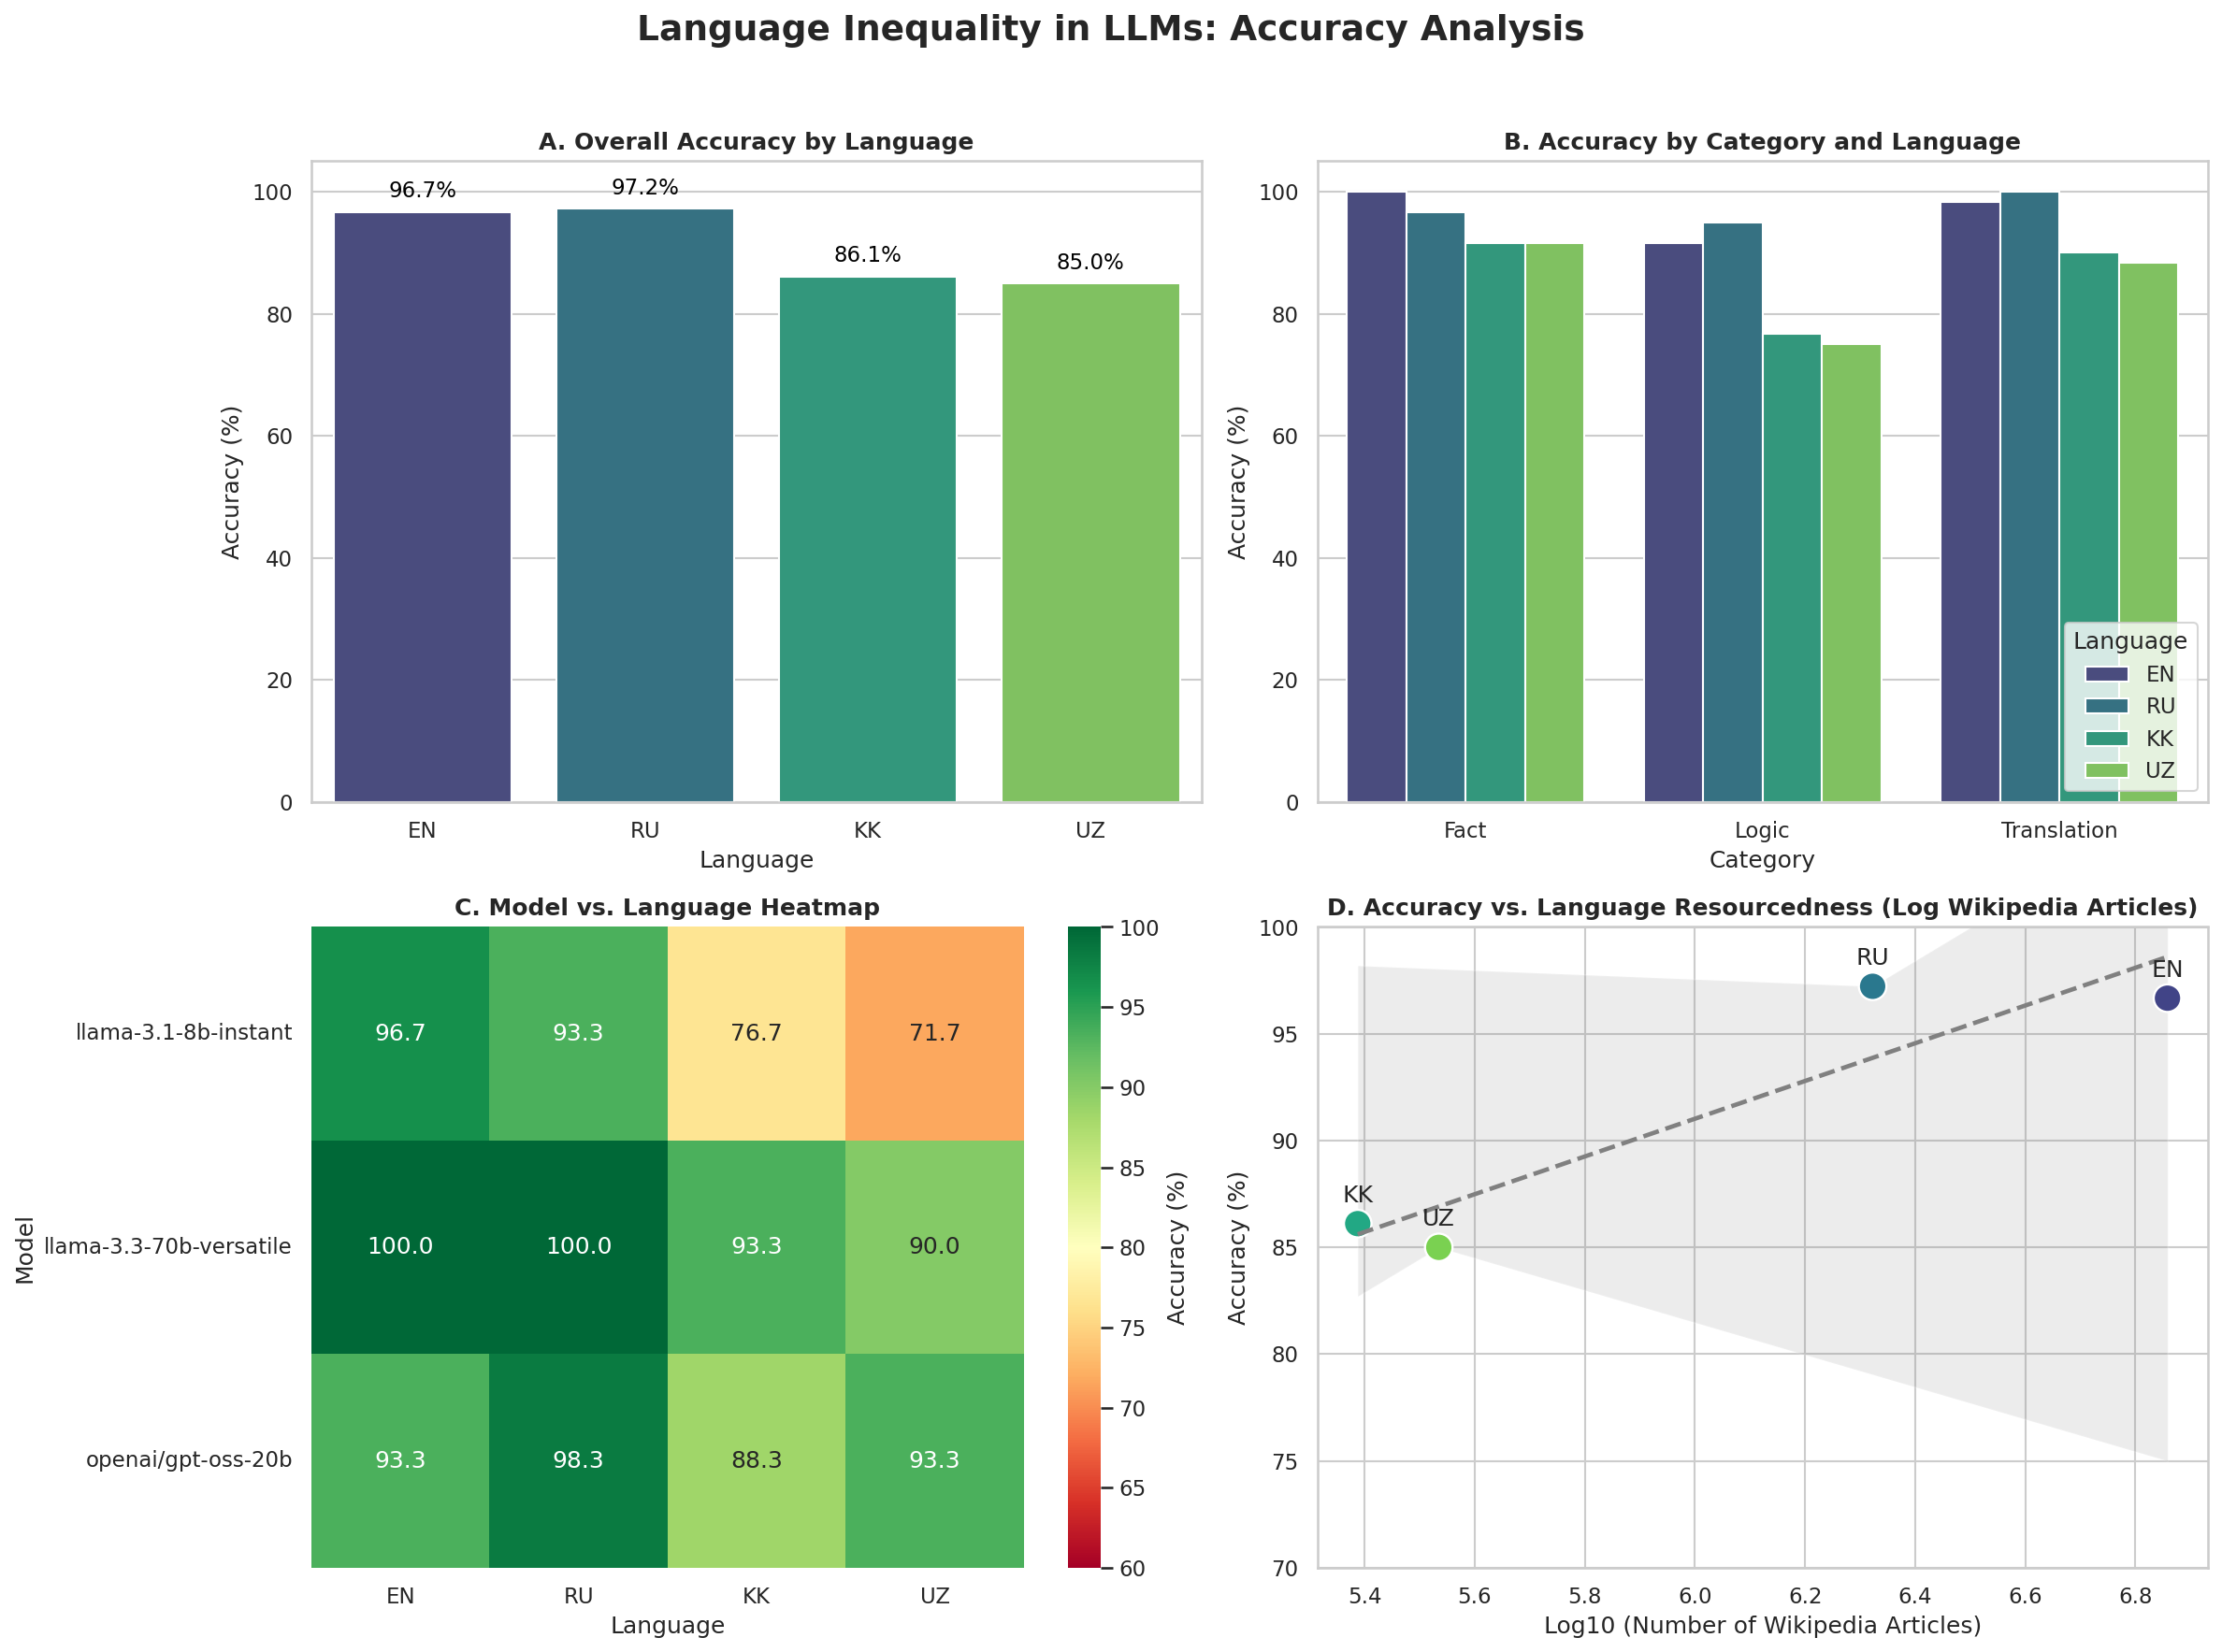

✅ Графики успешно построены и сохранены как 'sprint3_analysis_charts.png'!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройки стиля для академических графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# 1. Загрузка данных (убедись, что имя файла совпадает с твоим)
INPUT_PATH = "results_all_models_scored.xlsx"
df = pd.read_excel(INPUT_PATH)

LANG_ORDER = ["EN", "RU", "KK", "UZ"]
CAT_ORDER = ["Fact", "Logic", "Translation"]

# Умножаем на 100 для отображения в процентах
df['accuracy_pct'] = df['correctness_score'] * 100

# Создаем фигуру с 4 подграфиками (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Language Inequality in LLMs: Accuracy Analysis', fontsize=18, fontweight='bold', y=0.98)

# =========================================================
# График 1: Общая точность по языкам (Bar Chart)
# =========================================================
ax1 = axes[0, 0]
overall_acc = df.groupby('language')['accuracy_pct'].mean().reindex(LANG_ORDER).reset_index()
sns.barplot(data=overall_acc, x='language', y='accuracy_pct', palette="viridis", ax=ax1)
ax1.set_title("A. Overall Accuracy by Language", fontweight='bold')
ax1.set_ylabel("Accuracy (%)")
ax1.set_xlabel("Language")
ax1.set_ylim(0, 105)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

# =========================================================
# График 2: Точность по категориям и языкам (Grouped Bar)
# =========================================================
ax2 = axes[0, 1]
cat_acc = df.groupby(['category', 'language'])['accuracy_pct'].mean().reset_index()
cat_acc['language'] = pd.Categorical(cat_acc['language'], categories=LANG_ORDER, ordered=True)
sns.barplot(data=cat_acc, x='category', y='accuracy_pct', hue='language', palette="viridis", order=CAT_ORDER, ax=ax2)
ax2.set_title("B. Accuracy by Category and Language", fontweight='bold')
ax2.set_ylabel("Accuracy (%)")
ax2.set_xlabel("Category")
ax2.set_ylim(0, 105)
ax2.legend(title='Language', loc='lower right')

# =========================================================
# График 3: Тепловая карта (Модель x Язык)
# =========================================================
ax3 = axes[1, 0]
heatmap_data = df.groupby(['model', 'language'])['accuracy_pct'].mean().unstack()[LANG_ORDER]
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn", vmin=60, vmax=100,
            cbar_kws={'label': 'Accuracy (%)'}, ax=ax3, annot_kws={"size": 12})
ax3.set_title("C. Model vs. Language Heatmap", fontweight='bold')
ax3.set_ylabel("Model")
ax3.set_xlabel("Language")

# =========================================================
# График 4: Scatter plot (Точность vs Объем Википедии) - H3
# =========================================================
ax4 = axes[1, 1]
# Данные из твоего анализа
wiki_articles = {"EN": 7214814, "RU": 2102124, "KK": 244000, "UZ": 342451}
log_wiki = {k: np.log10(v) for k, v in wiki_articles.items()}

scatter_df = overall_acc.copy()
scatter_df['log_wiki'] = scatter_df['language'].map(log_wiki)

sns.regplot(data=scatter_df, x='log_wiki', y='accuracy_pct', scatter=False, color='grey', ax=ax4, line_kws={"linestyle":"--"})
sns.scatterplot(data=scatter_df, x='log_wiki', y='accuracy_pct', hue='language', s=200, palette="viridis", ax=ax4, legend=False)

# Подписи точек
for i, row in scatter_df.iterrows():
    ax4.text(row['log_wiki'], row['accuracy_pct'] + 1, row['language'], fontsize=12, ha='center')

ax4.set_title("D. Accuracy vs. Language Resourcedness (Log Wikipedia Articles)", fontweight='bold')
ax4.set_ylabel("Accuracy (%)")
ax4.set_xlabel("Log10 (Number of Wikipedia Articles)")
ax4.set_ylim(70, 100)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("sprint3_analysis_charts.png", bbox_inches='tight')
plt.show()

print("✅ Графики успешно построены и сохранены как 'sprint3_analysis_charts.png'!")